In [25]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import eelbrain
from scipy.io import loadmat

SUBJECTS = helper_functions.get_subjects()

# Make envelope onset predictor

In [26]:
fdim = eelbrain.Scalar('frequency', [0])

for SUBJECT in SUBJECTS:

    dst_dir = file_paths.ENVELOPES_DIR / SUBJECT
    dst_dir.mkdir(exist_ok=True, parents=True)
    
    attended_onset_dst = dst_dir / f'{SUBJECT}_attended_envelope_onset.pickle'
    unattended_onset_dst = dst_dir / f'{SUBJECT}_unattended_envelope_onset.pickle'

    if attended_onset_dst.exists() and unattended_onset_dst.exists():
        print(f"Onset predictors for subject {SUBJECT} already exist. Skipping...")
        continue
    
    att_envelope_onset_trials = []
    unatt_envelope_onset_trials = []
    
    print("-" * 50)
    print(f"Processing subject {SUBJECT}...")
    
    attended_envelope_path = dst_dir / f"{SUBJECT}_attended_envelope.pickle"
    unattended_envelope_path = dst_dir / f"{SUBJECT}_unattended_envelope.pickle"

    if not attended_envelope_path.exists() or not unattended_envelope_path.exists():
        print(f"Envelope files for subject {SUBJECT} not found. Skipping...")
        continue

    # Load envelopes (these should already be NDVars)
    attended_envelope = eelbrain.load.unpickle(
        file_paths.ENVELOPES_DIR / SUBJECT / f"{SUBJECT}_attended_envelope.pickle"
    )
    unattended_envelope = eelbrain.load.unpickle(
        file_paths.ENVELOPES_DIR / SUBJECT / f"{SUBJECT}_unattended_envelope.pickle"
    )

    for att_ndvar, unatt_ndvar in zip([attended_envelope], [unattended_envelope]):

        # -------------------------------------------------
        # 1. Resample to 1000 Hz (required by edge detector)
        # -------------------------------------------------
        att_ndvar_1000 = eelbrain.resample(att_ndvar, 1000)
        unatt_ndvar_1000 = eelbrain.resample(unatt_ndvar, 1000)

        # -------------------------------------------------
        # 2. Add frequency dimension (make it 2D)
        # -------------------------------------------------
        att_2d = att_ndvar_1000.x[None, :]
        unatt_2d = unatt_ndvar_1000.x[None, :]

        att_ndvar_2d = eelbrain.NDVar(
            att_2d,
            dims=(fdim, att_ndvar_1000.time),
            name='attended'
        )

        unatt_ndvar_2d = eelbrain.NDVar(
            unatt_2d,
            dims=(fdim, unatt_ndvar_1000.time),
            name='unattended'
        )

        # -------------------------------------------------
        # 3. Run edge detector
        # -------------------------------------------------
        att_onset = eelbrain.edge_detector(att_ndvar_2d, c=30, name='attended_onset')
        unatt_onset = eelbrain.edge_detector(unatt_ndvar_2d, c=30, name='unattended_onset')

        # -------------------------------------------------
        # 4. Back to original sampling rate (64 Hz)
        # -------------------------------------------------
        att_onset = eelbrain.resample(att_onset, 64)
        unatt_onset = eelbrain.resample(unatt_onset, 64)

        # (optional) remove fake frequency dim again
        att_onset = att_onset.mean('frequency')
        unatt_onset = unatt_onset.mean('frequency')

        att_envelope_onset_trials.append(att_onset)
        unatt_envelope_onset_trials.append(unatt_onset)

    # -------------------------------------------------
    # 5. Concatenate + save
    # -------------------------------------------------
    att_concat = eelbrain.concatenate(att_envelope_onset_trials)
    unatt_concat = eelbrain.concatenate(unatt_envelope_onset_trials)

    eelbrain.save.pickle(att_concat, attended_onset_dst)
    eelbrain.save.pickle(unatt_concat, unattended_onset_dst)

Onset predictors for subject S1 already exist. Skipping...
Onset predictors for subject S2 already exist. Skipping...
Onset predictors for subject S3 already exist. Skipping...
Onset predictors for subject S4 already exist. Skipping...
Onset predictors for subject S5 already exist. Skipping...
Onset predictors for subject S6 already exist. Skipping...
Onset predictors for subject S7 already exist. Skipping...
Onset predictors for subject S8 already exist. Skipping...
Onset predictors for subject S9 already exist. Skipping...
Onset predictors for subject S10 already exist. Skipping...
Onset predictors for subject S11 already exist. Skipping...
Onset predictors for subject S12 already exist. Skipping...
Onset predictors for subject S13 already exist. Skipping...
Onset predictors for subject S14 already exist. Skipping...
Onset predictors for subject S15 already exist. Skipping...
Onset predictors for subject S16 already exist. Skipping...
Onset predictors for subject S17 already exist. S

(<NDVar 'attended': 192000 time>, <NDVar 'attended_onset': 192000 time>)

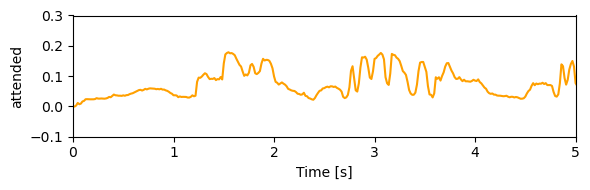

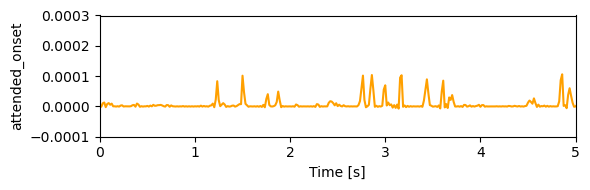

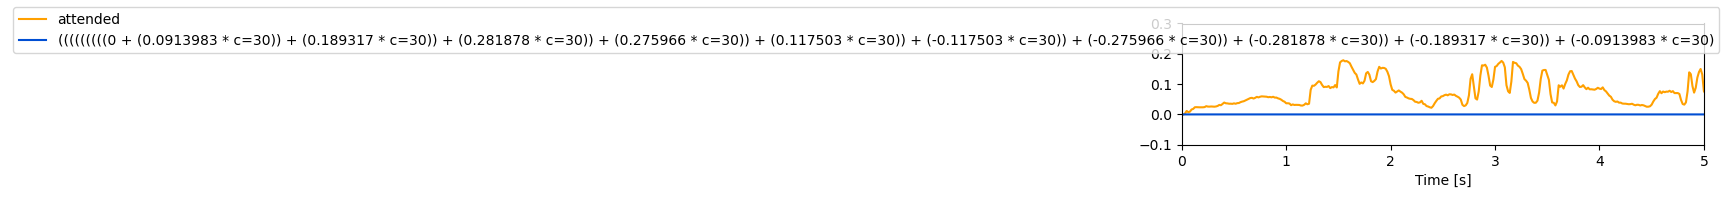

In [ ]:
# Load envelopes (these should already be NDVars)
envelope = eelbrain.load.unpickle(
    file_paths.ENVELOPES_DIR / SUBJECT / f"{SUBJECT}_attended_envelope.pickle"
)
onset = eelbrain.load.unpickle(
    file_paths.ENVELOPES_DIR / SUBJECT / f'{SUBJECT}_attended_envelope_onset.pickle'
)

# Sanity check: plot envelope and onset envelope for one trial
eelbrain.plot.UTS([[envelope]], xlim=5, w=6, h=2)
eelbrain.plot.UTS([[onset]], xlim=5, w=6, h=2)
eelbrain.plot.UTS([[envelope, onset]], xlim=5, w=6, h=2)

envelope, onset